## Training data on a logistic model

In [29]:
# Importing necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

In [3]:
# Setting the random seed for reproducibility
RSEED = 55

In [4]:
# Loading the dataset
df_diabetes = pd.read_csv('/Users/saidalkildani/Desktop/DS_AI/Projects/ML_diabetes_SA/ml-diabetes-SA/ML_diabetes_clean.csv')

In [5]:
df_diabetes.describe()

,id,Age,pregnancies,bmi,insulin,glucose,bloodpressure,skinthickness,diabetespedigreefunction,outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,384.500000,33.240885,3.845052,31.992578,79.799479,120.894531,69.105469,20.536458,0.471876,0.348958
std,221.846794,11.760232,3.369578,7.884160,115.244002,31.972618,19.355807,15.952218,0.331329,0.476951
min,1.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,0.000000
25%,192.750000,24.000000,1.000000,27.300000,0.000000,99.000000,62.000000,0.000000,0.243750,0.000000
50%,384.500000,29.000000,3.000000,32.000000,30.500000,117.000000,72.000000,23.000000,0.372500,0.000000
75%,576.250000,41.000000,6.000000,36.600000,127.250000,140.250000,80.000000,32.000000,0.626250,1.000000
max,768.000000,81.000000,17.000000,67.100000,846.000000,199.000000,122.000000,99.000000,2.420000,1.000000


In [12]:
df_diabetes

,id,Age,pregnancies,bmi,insulin,glucose,bloodpressure,skinthickness,diabetespedigreefunction,outcome
0,1,50,6,33.6,0,148,72,35,0.627,1
1,2,31,1,26.6,0,85,66,29,0.351,0
2,3,32,8,23.3,0,183,64,0,0.672,1
3,4,21,1,28.1,94,89,66,23,0.167,0
4,5,33,0,43.1,168,137,40,35,2.288,1
...,...,...,...,...,...,...,...,...,...,...
763,764,63,10,32.9,180,101,76,48,0.171,0
764,765,27,2,36.8,0,122,70,27,0.340,0
765,766,30,5,26.2,112,121,72,23,0.245,0
766,767,47,1,30.1,0,126,60,0,0.349,1


In [6]:
y = df_diabetes['outcome']
X = df_diabetes.copy().drop(['id', 'outcome'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=RSEED)

In [7]:
# Imputing zeros and replacing them with mean of feature (X_train, to avoid data leakage)
columns_to_fix = ['insulin', 'glucose', 'bloodpressure', 'bmi', 'skinthickness']
for col in columns_to_fix:
    non_zero_mean = X_train.loc[X_train[col] != 0, col].mean()
    X_train.loc[X_train[col] == 0, col] = non_zero_mean
for col in columns_to_fix:
    non_zero_mean = X_train.loc[X_train[col] != 0, col].mean()
    X_test.loc[X_test[col] == 0, col] = non_zero_mean    

In [8]:
# Evaluation fucntion
def eval_model(model_name, y_actual, y_pred):
    conf_matrix = confusion_matrix(y_actual, y_pred)
    sns.heatmap(conf_matrix, annot=True, fmt="d");

    # Print accuracy of our model
    print(f"Accuracy {model_name}: {round(accuracy_score(y_actual, y_pred), 2)}")
    print("--------"*10)

    # Print classification report of our model
    print(classification_report(y_actual, y_pred))
    print("--------"*10)
    plt.show


<Axes: xlabel='outcome', ylabel='count'>

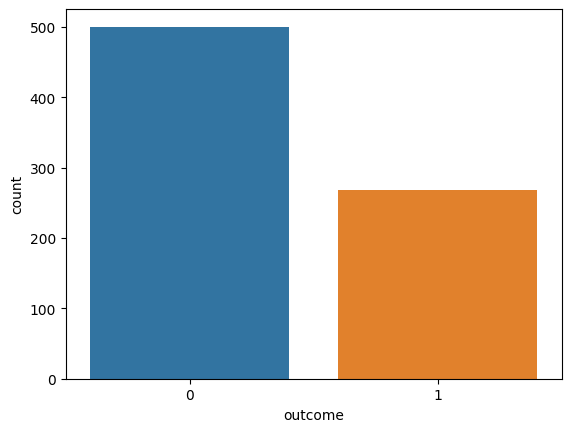

In [28]:
# is my data imbalanced?
sns.countplot(x='outcome', data=df_diabetes)

### Baseline Model: Logistic Model

In [9]:
# Normalise features
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

Accuracy All normalised features logistic model, training data: 0.79
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       358
           1       0.73      0.59      0.65       179

    accuracy                           0.79       537
   macro avg       0.77      0.74      0.75       537
weighted avg       0.78      0.79      0.78       537

--------------------------------------------------------------------------------


/Users/saidalkildani/Desktop/DS_AI/Projects/ML_diabetes_SA/ml-diabetes-SA/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


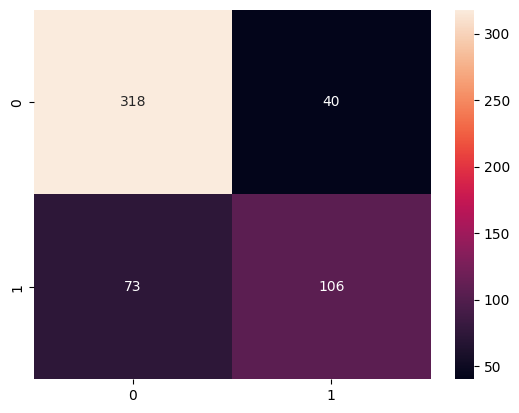

In [10]:
# Fit logistic model
## Fit model
lr = LogisticRegression()
lr.fit(X_train, y_train)

## Predicting on the test set
y_pred_test = lr.predict(X_test)
y_pred_train = lr.predict(X_train)

## Evaluating the model
eval_model("All normalised features logistic model, training data", y_train, y_pred_train)

Accuracy All normalised features logistic model, testing data: 0.71
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.73      0.84      0.78       142
           1       0.66      0.49      0.56        89

    accuracy                           0.71       231
   macro avg       0.69      0.67      0.67       231
weighted avg       0.70      0.71      0.70       231

--------------------------------------------------------------------------------


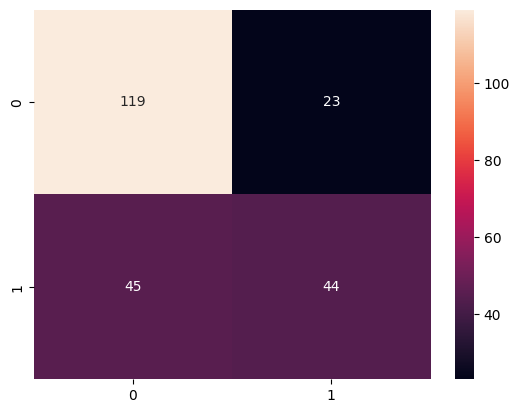

In [11]:
## Evaluating the model
eval_model("All normalised features logistic model, testing data", y_test, y_pred_test)

### Building a Pipeline

In [ ]:
# Load raw data again
df_diabetes = pd.read_csv('/Users/saidalkildani/Desktop/DS_AI/Projects/ML_diabetes_SA/ml-diabetes-SA/ML_diabetes_clean.csv')

In [17]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
## Building a pipeline 
pipeline = Pipeline([
    ('imputer', KNNImputer()), 
    ('scaler', MinMaxScaler()),
    ('clf', LogisticRegression()) #placeholder
])

param_grid = [
    {
        'clf': [LogisticRegression(max_iter=1000)],
        'clf__C': [0.1, 1, 10], #Regularisation strength
        'clf__solver': ['lbfgs'] #Optimizes algorithm
    },
    {
        'clf': [RandomForestClassifier()],
        'clf__n_estimators': [50, 100], #Number of trees
        'clf__max_depth': [5, 1] #Maximum depth of the tree
    },
    {
        'clf': [XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')],
        'clf__n_estimators': [100], #Number of trees
        'clf__max_depth': [3, 5],#Maximum depth of the tree
        'clf__learning_rate': [0.1] #Learning rate
    },
     {
        'imputer': [KNNImputer()]
    },
    {
        'imputer': [SimpleImputer(strategy='mean')]
    }
]


In [26]:
# Perform a grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, scoring='f1')
grid_search.fit(X_train, y_train)

# Show results
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'clf': LogisticRegression(C=1, max_iter=1000), 'clf__C': 1, 'clf__solver': 'lbfgs'}
Best cross-validation score: 0.6595510886710065


/Users/saidalkildani/Desktop/DS_AI/Projects/ML_diabetes_SA/ml-diabetes-SA/.venv/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [16:54:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/saidalkildani/Desktop/DS_AI/Projects/ML_diabetes_SA/ml-diabetes-SA/.venv/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [16:54:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/saidalkildani/Desktop/DS_AI/Projects/ML_diabetes_SA/ml-diabetes-SA/.venv/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [16:54:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/saidalkildani/Desktop/DS_AI/Projects/ML

In [24]:
grid_search.best_estimator_

Pipeline(steps=[('imputer', KNNImputer()), ('scaler', MinMaxScaler()),
                ('clf', LogisticRegression(C=1, max_iter=1000))])